In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/mental_health_clean.csv')
print(df.shape)
df.head()

(11479, 13)


,YearStart,YearEnd,LocationAbbr,LocationDesc,Topic,Question,DataValue,DataValueUnit,DataValueType,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2
0,2019,2019,AL,Alabama,Mental Health,Frequent mental distress among adults,21.0,%,Crude Prevalence,Age,Age 18-44,NaN,Overall
1,2019,2019,AR,Arkansas,Mental Health,Depression among adults,27.8,%,Crude Prevalence,Age,Age 18-44,NaN,Overall
2,2019,2019,GU,Guam,Mental Health,Depression among adults,13.0,%,Age-adjusted Prevalence,Race/Ethnicity,"Multiracial, non-Hispanic",NaN,Overall
3,2019,2019,ID,Idaho,Mental Health,Depression among adults,22.3,%,Crude Prevalence,Age,Age 45-64,NaN,Overall
4,2019,2019,ID,Idaho,Mental Health,Frequent mental distress among adults,11.5,%,Crude Prevalence,Sex,Male,NaN,Overall


In [5]:
import os
os.makedirs('../visuals', exist_ok=True)
print("visuals folder created!")

visuals folder created!


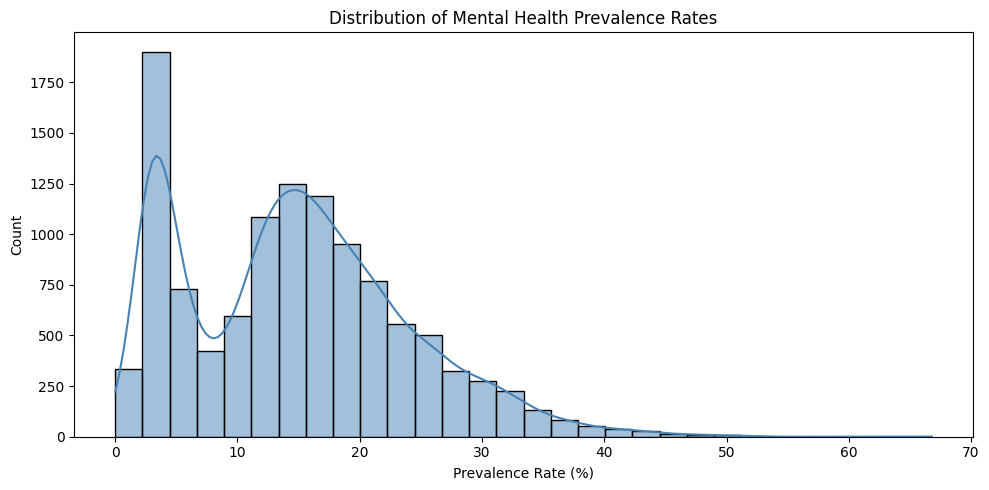

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['DataValue'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Mental Health Prevalence Rates')
plt.xlabel('Prevalence Rate (%)')
plt.tight_layout()
plt.savefig('../visuals/distribution.png')
plt.show()

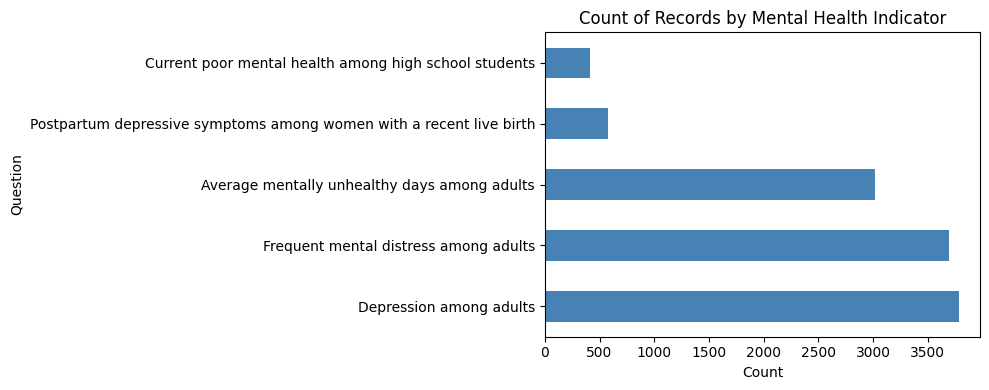

In [7]:
plt.figure(figsize=(10,4))
df['Question'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Count of Records by Mental Health Indicator')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('../visuals/question_counts.png')
plt.show()

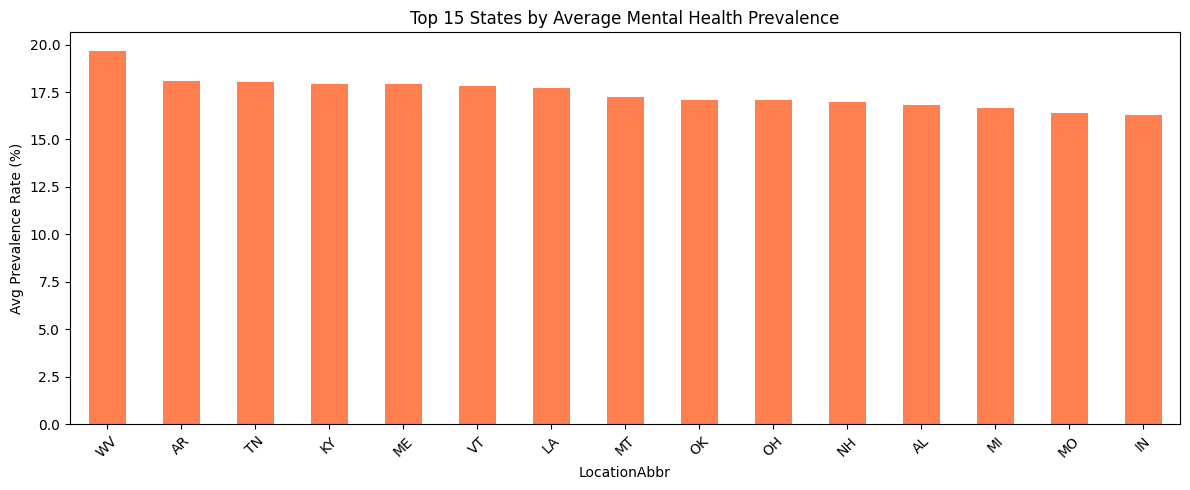

In [8]:
state_avg = df.groupby('LocationAbbr')['DataValue'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12,5))
state_avg.plot(kind='bar', color='coral')
plt.title('Top 15 States by Average Mental Health Prevalence')
plt.ylabel('Avg Prevalence Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/top_states.png')
plt.show()

In [10]:
print(df['StratificationCategory1'].unique())
print(df['StratificationCategory1'].value_counts())

['Age' 'Race/Ethnicity' 'Sex' 'Overall' 'Grade']
StratificationCategory1
Race/Ethnicity    5457
Sex               2587
Age               1875
Overall           1420
Grade              140
Name: count, dtype: int64


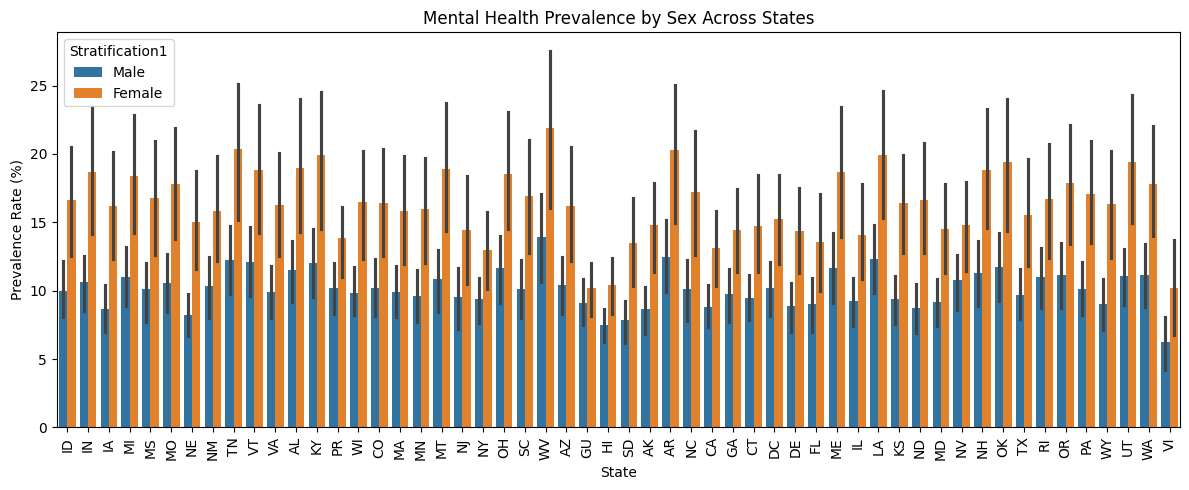

In [11]:
gender_df = df[df['StratificationCategory1'] == 'Sex']

plt.figure(figsize=(12,5))
sns.barplot(data=gender_df, x='LocationAbbr', y='DataValue', hue='Stratification1')
plt.title('Mental Health Prevalence by Sex Across States')
plt.xlabel('State')
plt.ylabel('Prevalence Rate (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../visuals/gender_breakdown.png')
plt.show()

C:\Users\jaswa\AppData\Local\Temp\ipykernel_9724\2876739112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_df, x='Stratification1', y='DataValue', palette='Blues')


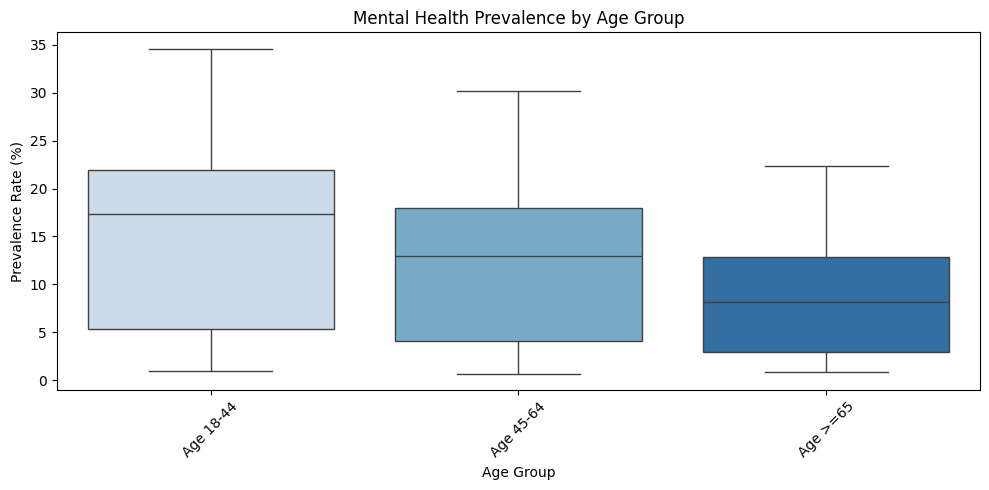

In [12]:
age_df = df[df['StratificationCategory1'] == 'Age']

plt.figure(figsize=(10,5))
sns.boxplot(data=age_df, x='Stratification1', y='DataValue', palette='Blues')
plt.title('Mental Health Prevalence by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Prevalence Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/age_breakdown.png')
plt.show()

C:\Users\jaswa\AppData\Local\Temp\ipykernel_9724\3995082312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=race_df, x='Stratification1', y='DataValue', palette='Set2')


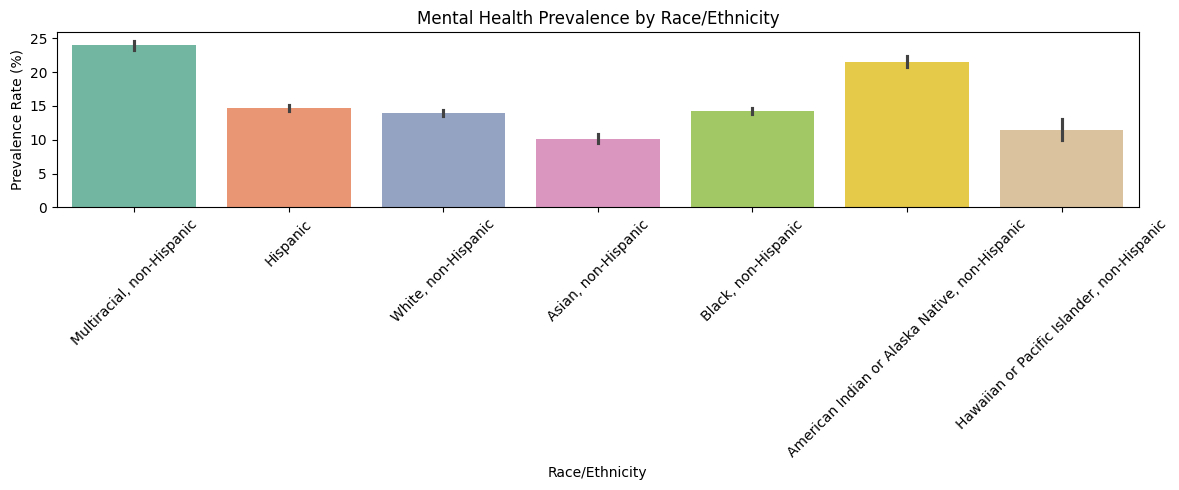

In [13]:
race_df = df[df['StratificationCategory1'] == 'Race/Ethnicity']

plt.figure(figsize=(12,5))
sns.barplot(data=race_df, x='Stratification1', y='DataValue', palette='Set2')
plt.title('Mental Health Prevalence by Race/Ethnicity')
plt.xlabel('Race/Ethnicity')
plt.ylabel('Prevalence Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/race_breakdown.png')
plt.show()